# 02. Exploratory Data Analysis

This notebook explores feature distributions, missing value patterns, and dataset characteristics that may influence preprocessing and model selection.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Environment Setup

In [6]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root configured.")

Project root configured.


In [7]:
from src.churn_ml.data import (
    analyze_cardinality,
    analyze_feature_types,
    analyze_missing_values,
    analyze_numeric_features,
    load_competition_data,
)

from src.churn_ml.data import (
    analyze_categorical_features,
    categorize_cardinality,
    categorize_missing_rate,
    categorize_top_rate,
)

from src.churn_ml.visualization import (
    plot_categorical_distribution,
    plot_numeric_distribution,
)
from src.churn_ml.experiment import Experiment


## Dataset Loading

In [8]:
data = load_competition_data(
    train_path=PROJECT_ROOT / "data/raw/final_proj_data.csv",
    test_path=PROJECT_ROOT / "data/raw/final_proj_test.csv",
    sample_submission_path=(
        PROJECT_ROOT / "data/raw/final_proj_sample_submission.csv"
    ),
)

print("Train:", data.train.shape)
print("Test:", data.test.shape)

Train: (10000, 231)
Test: (2500, 230)


## Experiment Initialization

In [9]:
experiment = Experiment(
    name="eda_002_missing_values_analysis",
    model_type="eda",
    description="Exploratory analysis of missing value patterns",
    notes=(
        "Analysis of feature-level missing values "
        "to support preprocessing decisions."
    ),
    seed=42,
    train_path=PROJECT_ROOT / "data/raw/final_proj_data.csv",
    test_path=PROJECT_ROOT / "data/raw/final_proj_test.csv",
)

experiment.summary()

{'run_id': '20260722_210807_eda_002_missing_values_analysis',
 'name': 'eda_002_missing_values_analysis',
 'model_type': 'eda',
 'status': 'running',
 'artifact_path': 'artifacts\\experiments\\20260722_210807_eda_002_missing_values_analysis'}

## Missing Values Analysis

In [10]:
missing_summary = analyze_missing_values(data.X)

display(missing_summary.head(20))

,column,n_rows,n_missing,n_present,missing_rate,missing_bucket
0,Var141,10000,10000,0,1.0000,All missing
1,Var15,10000,10000,0,1.0000,All missing
2,Var167,10000,10000,0,1.0000,All missing
3,Var169,10000,10000,0,1.0000,All missing
4,Var175,10000,10000,0,1.0000,All missing
5,Var185,10000,10000,0,1.0000,All missing
6,Var20,10000,10000,0,1.0000,All missing
7,Var209,10000,10000,0,1.0000,All missing
8,Var230,10000,10000,0,1.0000,All missing
9,Var31,10000,10000,0,1.0000,All missing


In [11]:
missing_bucket_summary = (
    missing_summary
    .groupby(
        "missing_bucket",
        observed=True,
        sort=False,
    )
    .agg(
        feature_count=("column", "count"),
        total_missing=("n_missing", "sum"),
    )
    .reset_index()
)

missing_bucket_summary["feature_rate"] = (
    missing_bucket_summary["feature_count"]
    / len(missing_summary)
)

missing_bucket_summary["feature_rate_pct"] = (
    missing_bucket_summary["feature_rate"] * 100
).round(1)

display(missing_bucket_summary)

,missing_bucket,feature_count,total_missing,feature_rate,feature_rate_pct
0,All missing,18,180000,0.078261,7.8
1,Very high (75–100%),136,1332204,0.591304,59.1
2,High (50–75%),5,31398,0.021739,2.2
3,Moderate (25–50%),5,21466,0.021739,2.2
4,Low (<25%),45,38381,0.195652,19.6
5,No missing,21,0,0.091304,9.1


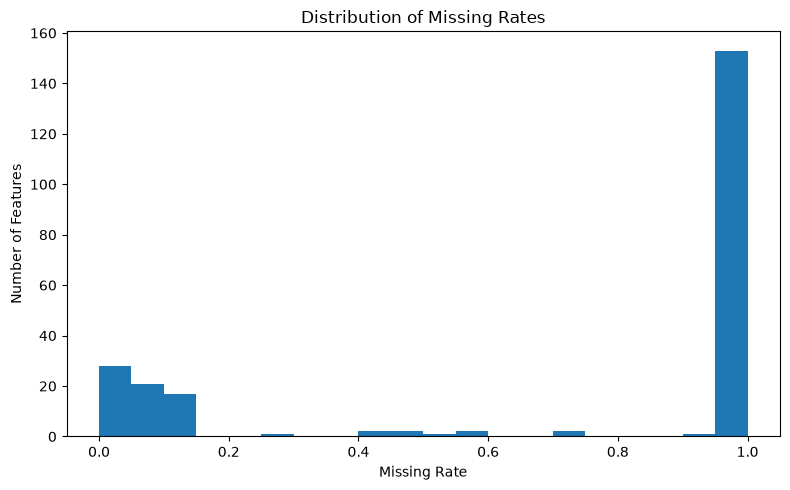

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    missing_summary["missing_rate"],
    bins=20,
)

plt.title("Distribution of Missing Rates")
plt.xlabel("Missing Rate")
plt.ylabel("Number of Features")

plt.tight_layout()
plt.show()

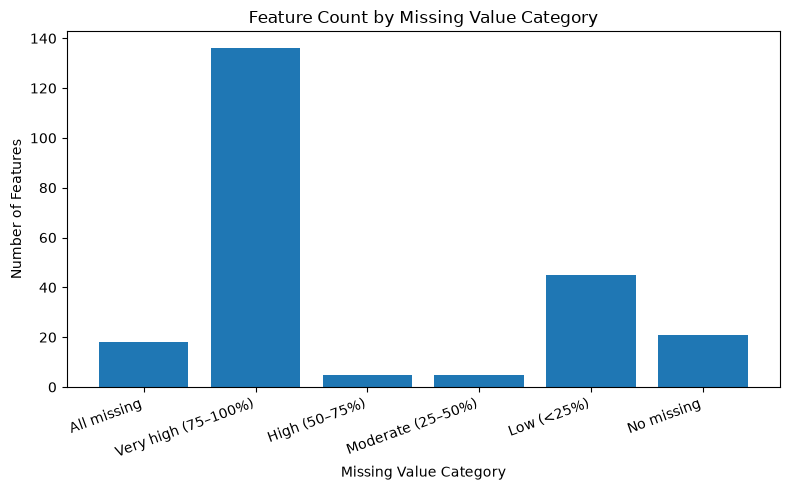

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    missing_bucket_summary["missing_bucket"],
    missing_bucket_summary["feature_count"],
)

plt.title("Feature Count by Missing Value Category")
plt.xlabel("Missing Value Category")
plt.ylabel("Number of Features")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

In [14]:
experiment.save_dataframe(
    missing_summary,
    "missing_summary.csv",
)

experiment.save_dataframe(
    missing_bucket_summary,
    "missing_bucket_summary.csv",
)

WindowsPath('artifacts/experiments/20260722_210807_eda_002_missing_values_analysis/reports/missing_bucket_summary.csv')

### Key Findings

- Missing values are highly prevalent across the dataset.
- A total of **154 out of 230 features** have at least **75% missing values**, including **18 fully missing features**.
- Only **21 features** contain no missing values.
- The dataset is therefore highly sparse, so models with native missing-value handling are likely to be strong baseline candidates.
- Features should not be removed based on missing rate alone, because highly sparse variables may still contain predictive signal.

## Feature Type Analysis

In [15]:
feature_type_summary = analyze_feature_types(data.X)

display(feature_type_summary)

,feature_type,feature_count,feature_rate,feature_rate_pct,description
0,Numeric,192,0.834783,83.5,Integer and floating-point features
1,Integer,1,0.004348,0.4,Integer features
2,Float,191,0.830435,83.0,Floating-point features
3,Boolean,0,0.000000,0.0,Boolean features
4,Object,38,0.165217,16.5,Object (string) features
5,Category,0,0.000000,0.0,Pandas categorical features


In [16]:
experiment.save_dataframe(
    feature_type_summary,
    "feature_type_summary.csv",
)

WindowsPath('artifacts/experiments/20260722_210807_eda_002_missing_values_analysis/reports/feature_type_summary.csv')

### Key Findings

- The dataset contains **192 numerical features** and **38 object features**.
- Almost all numerical variables are stored as floating-point values to support missing data representation.
- Only one feature is stored as an integer type, while no boolean or categorical (`category`) columns are present.
- Most preprocessing efforts will therefore focus on numerical features, with separate handling required for object features.

## Cardinality Analysis

In [17]:
cardinality_summary = analyze_cardinality(data.X)

display(cardinality_summary.head(20))

,column,dtype,n_unique,unique_rate,is_constant,cardinality_bucket
0,Var113,float64,9787,0.9787,False,High (>200)
1,Var81,float64,8826,0.8826,False,High (>200)
2,Var57,float64,8602,0.8602,False,High (>200)
3,Var153,float64,8242,0.8242,False,High (>200)
4,Var133,float64,7855,0.7855,False,High (>200)
5,Var134,float64,7080,0.7080,False,High (>200)
6,Var38,float64,6660,0.6660,False,High (>200)
7,Var76,float64,6437,0.6437,False,High (>200)
8,Var217,object,5529,0.5529,False,High (>200)
9,Var163,float64,5146,0.5146,False,High (>200)


In [18]:
display(
    cardinality_summary[
        cardinality_summary["dtype"] == "object"
    ]
)

,column,dtype,n_unique,unique_rate,is_constant,cardinality_bucket
8,Var217,object,5529,0.5529,False,High (>200)
11,Var200,object,4478,0.4478,False,High (>200)
12,Var214,object,4478,0.4478,False,High (>200)
15,Var202,object,3802,0.3802,False,High (>200)
16,Var198,object,2100,0.2100,False,High (>200)
17,Var220,object,2100,0.2100,False,High (>200)
18,Var222,object,2100,0.2100,False,High (>200)
19,Var199,object,1850,0.1850,False,High (>200)
23,Var216,object,977,0.0977,False,High (>200)
29,Var192,object,297,0.0297,False,High (>200)


In [19]:
cardinality_bucket_summary = (
    cardinality_summary
    .groupby(
        "cardinality_bucket",
        observed=True,
        sort=False,
    )
    .agg(
        feature_count=("column", "count"),
    )
    .reset_index()
)

cardinality_bucket_summary["feature_rate"] = (
    cardinality_bucket_summary["feature_count"]
    / len(cardinality_summary)
)

cardinality_bucket_summary["feature_rate_pct"] = (
    cardinality_bucket_summary["feature_rate"] * 100
).round(1)

display(cardinality_bucket_summary)

,cardinality_bucket,feature_count,feature_rate,feature_rate_pct
0,High (>200),32,0.139130,13.9
1,Medium (51–200),49,0.213043,21.3
2,Low (11–50),60,0.260870,26.1
3,Very low (3–10),50,0.217391,21.7
4,Binary,14,0.060870,6.1
5,Constant,7,0.030435,3.0
6,Empty,18,0.078261,7.8


In [20]:
experiment.save_dataframe(
    cardinality_summary,
    "cardinality_summary.csv",
)

experiment.save_dataframe(
    cardinality_bucket_summary,
    "cardinality_bucket_summary.csv",
)

WindowsPath('artifacts/experiments/20260722_210807_eda_002_missing_values_analysis/reports/cardinality_bucket_summary.csv')

### Key Findings

- Feature cardinality varies substantially across the dataset, ranging from empty and constant features to variables with nearly unique values for each observation.
- Thirty-two features contain more than 200 distinct values, including several numerical and object features with very high cardinality.
- The dataset contains 14 binary features and a large proportion of features with low to medium cardinality, providing diverse feature types for subsequent preprocessing.
- The Empty and Constant feature groups are fully consistent with the findings from the Data Audit and Missing Values Analysis, confirming the presence of non-informative features.

## Numerical Feature Distributions

In [21]:
numeric_summary = analyze_numeric_features(data.X)

display(numeric_summary.head(20))

,column,dtype,n_rows,n_missing,n_unique,mean,std,min,q1,median,q3,max,skewness,kurtosis,missing_rate,iqr,range,abs_skewness
0,Var83,float64,10000,920,108,21.181167,98.332477,0.0,0.0,10.0,25.0,4690.0,26.155132,918.443093,0.0920,25.0,4690.0,26.155132
1,Var123,float64,10000,920,159,62.597577,239.140170,0.0,6.0,30.0,72.0,9456.0,25.332244,853.065543,0.0920,66.0,9456.0,25.332244
2,Var125,float64,10000,1005,4197,27760.153307,88357.149792,0.0,261.0,6570.0,31855.5,3890952.0,25.090343,951.929967,0.1005,31594.5,3890952.0,25.090343
3,Var109,float64,10000,1360,122,64.139815,176.246791,0.0,24.0,32.0,64.0,7456.0,21.595046,658.860548,0.1360,40.0,7456.0,21.595046
4,Var173,float64,10000,920,2,0.004846,0.098332,0.0,0.0,0.0,0.0,2.0,20.245126,407.954972,0.0920,0.0,2.0,20.245126
5,Var74,float64,10000,1005,227,101.547082,296.598152,0.0,0.0,7.0,91.0,13783.0,18.050388,660.577104,0.1005,91.0,13783.0,18.050388
6,Var44,float64,10000,920,6,0.162555,1.611381,0.0,0.0,0.0,0.0,72.0,17.816443,538.687133,0.0920,0.0,72.0,17.816443
7,Var119,float64,10000,1020,816,913.434855,1925.708454,0.0,425.0,560.0,885.0,70265.0,17.604608,482.794900,0.1020,460.0,70265.0,17.604608
8,Var22,float64,10000,920,411,297.810573,688.436748,0.0,135.0,180.0,285.0,25885.0,16.536072,410.308583,0.0920,150.0,25885.0,16.536072
9,Var21,float64,10000,1020,411,240.702895,553.289430,0.0,112.0,144.0,232.0,20708.0,16.478526,407.000180,0.1020,120.0,20708.0,16.478526


In [22]:
display(
    numeric_summary[
        [
            "column",
            "n_missing",
            "n_unique",
            "mean",
            "std",
            "min",
            "median",
            "max",
            "skewness",
            "kurtosis",
        ]
    ].head(20)
)

,column,n_missing,n_unique,mean,std,min,median,max,skewness,kurtosis
0,Var83,920,108,21.181167,98.332477,0.0,10.0,4690.0,26.155132,918.443093
1,Var123,920,159,62.597577,239.140170,0.0,30.0,9456.0,25.332244,853.065543
2,Var125,1005,4197,27760.153307,88357.149792,0.0,6570.0,3890952.0,25.090343,951.929967
3,Var109,1360,122,64.139815,176.246791,0.0,32.0,7456.0,21.595046,658.860548
4,Var173,920,2,0.004846,0.098332,0.0,0.0,2.0,20.245126,407.954972
5,Var74,1005,227,101.547082,296.598152,0.0,7.0,13783.0,18.050388,660.577104
6,Var44,920,6,0.162555,1.611381,0.0,0.0,72.0,17.816443,538.687133
7,Var119,1020,816,913.434855,1925.708454,0.0,560.0,70265.0,17.604608,482.794900
8,Var22,920,411,297.810573,688.436748,0.0,180.0,25885.0,16.536072,410.308583
9,Var21,1020,411,240.702895,553.289430,0.0,144.0,20708.0,16.478526,407.000180


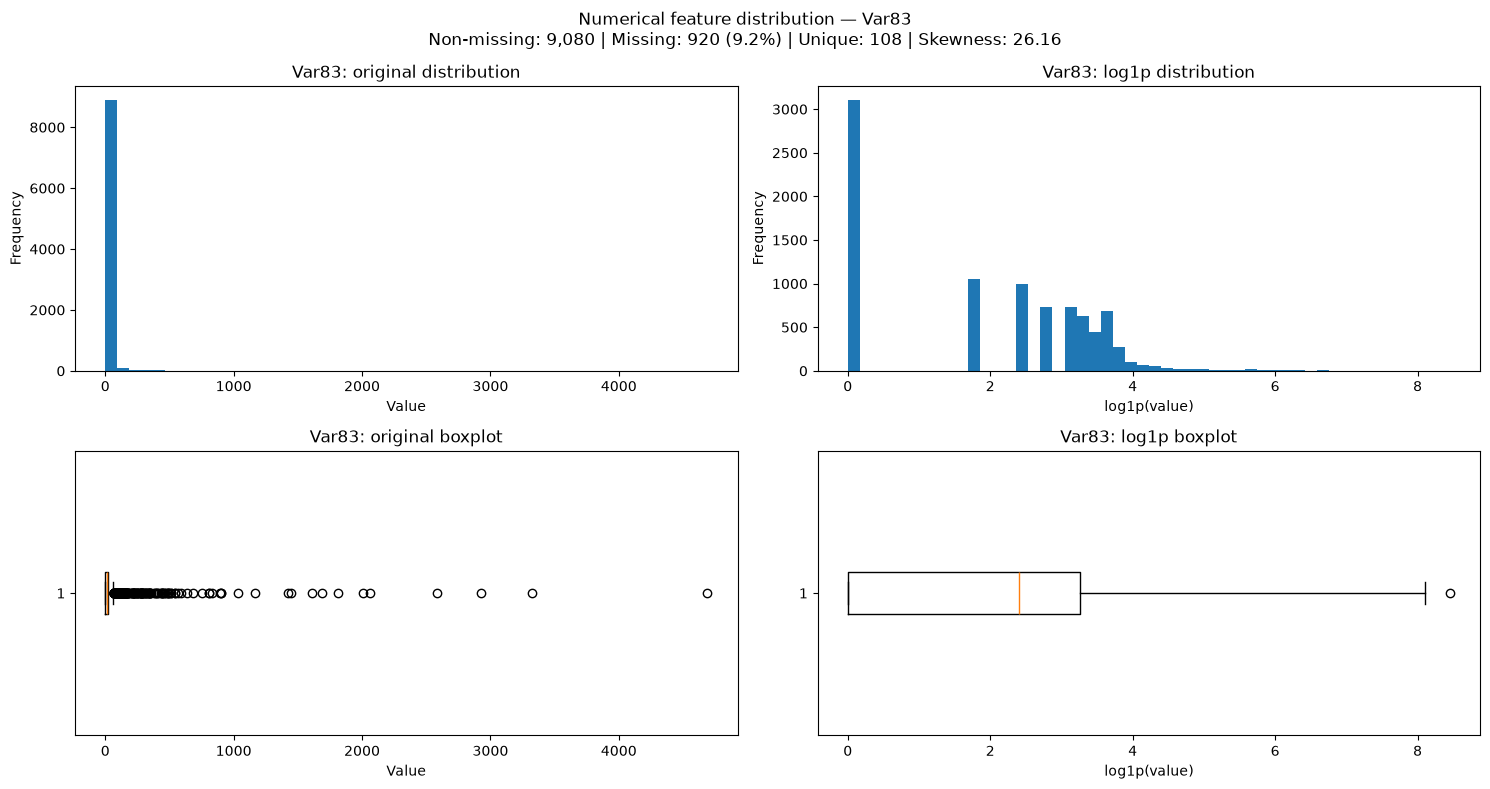

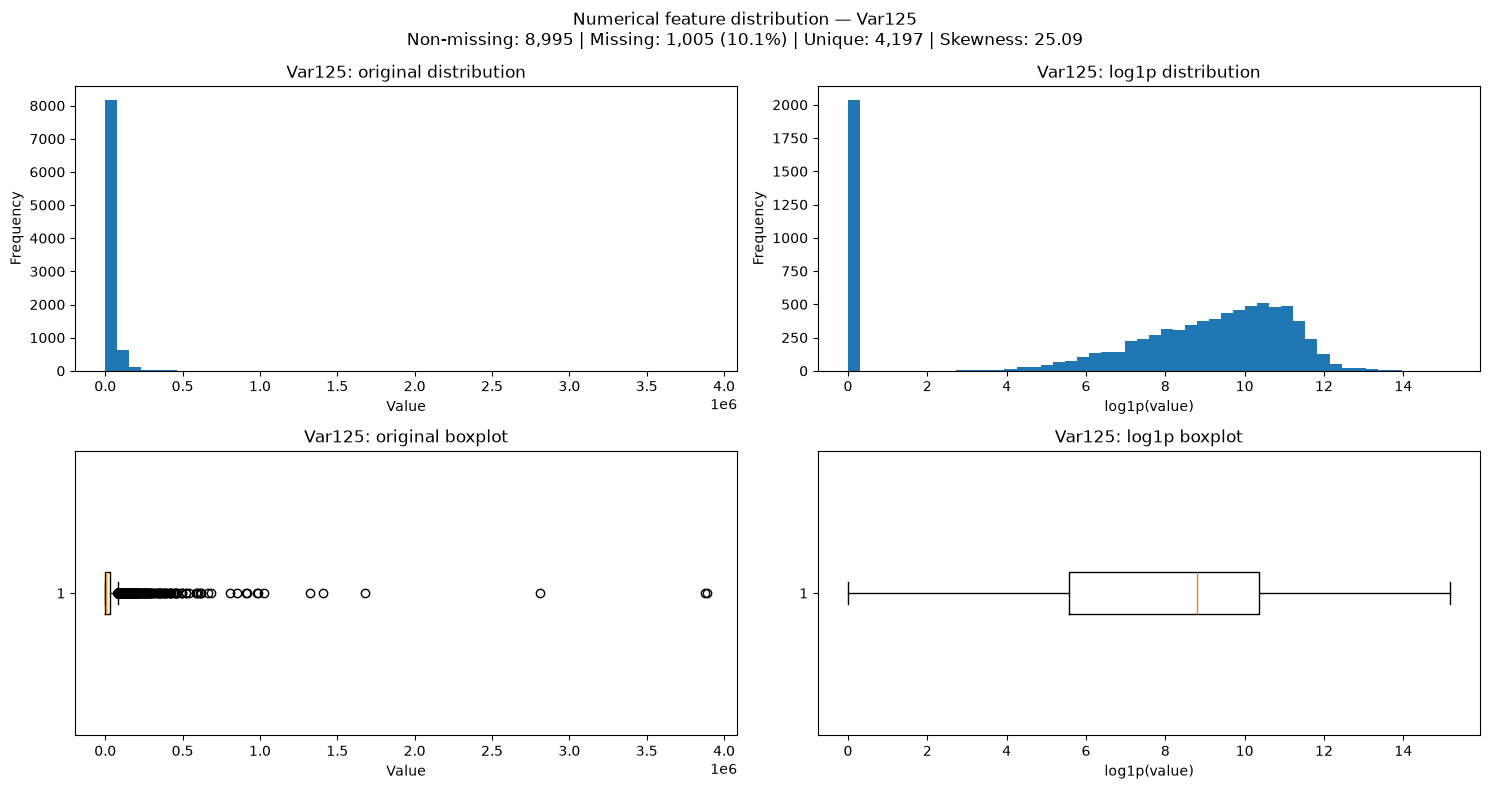

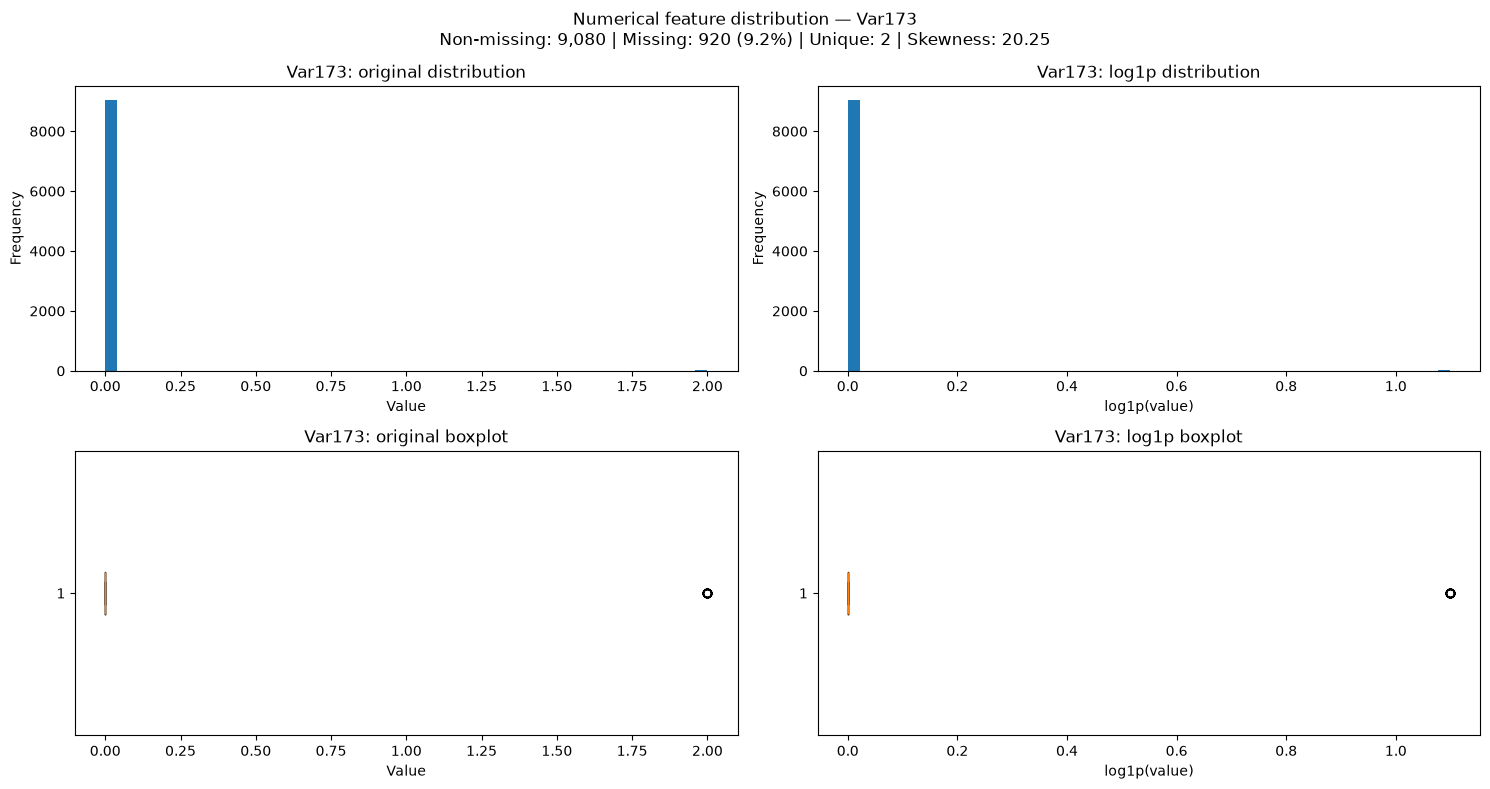

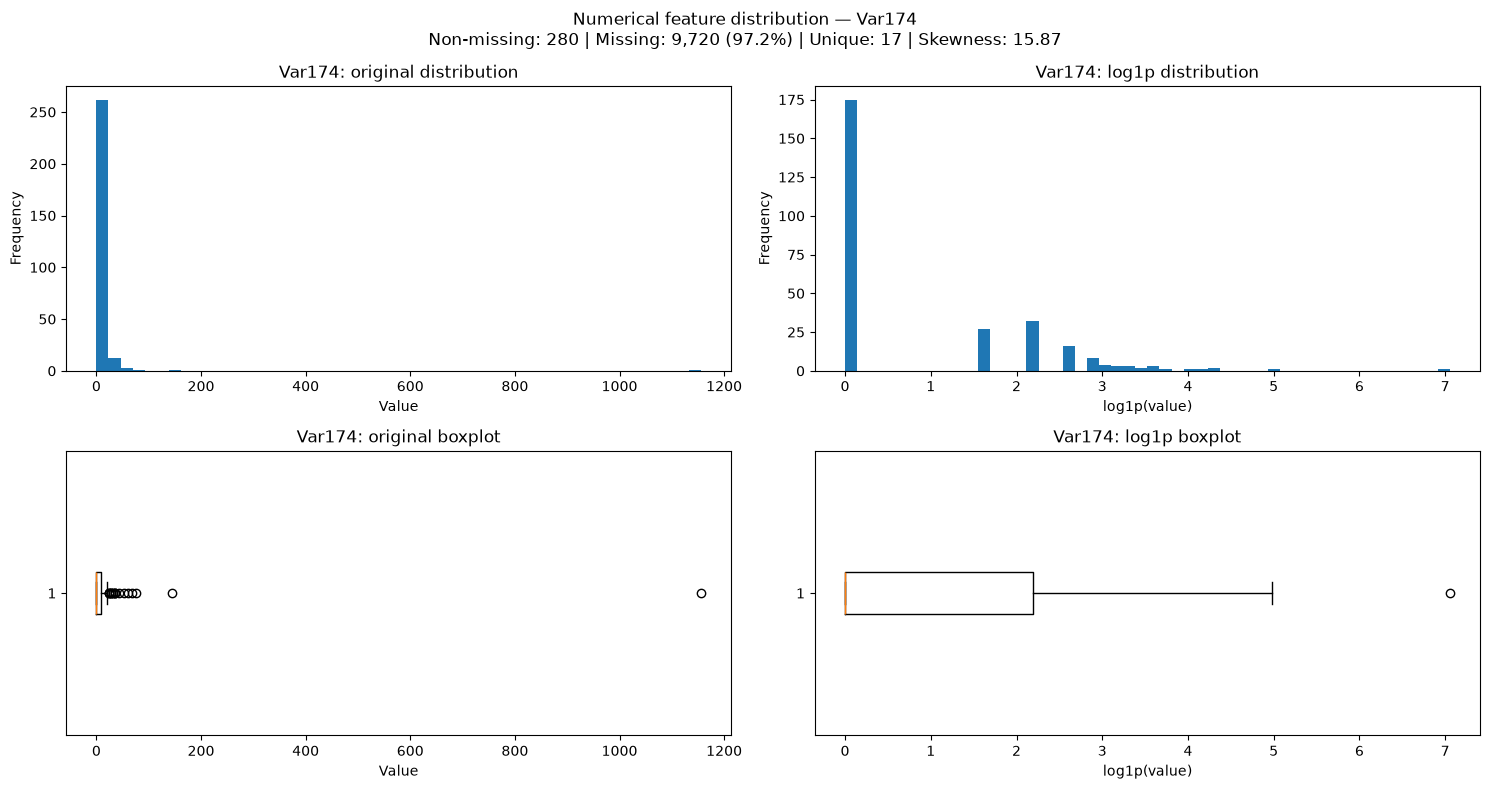

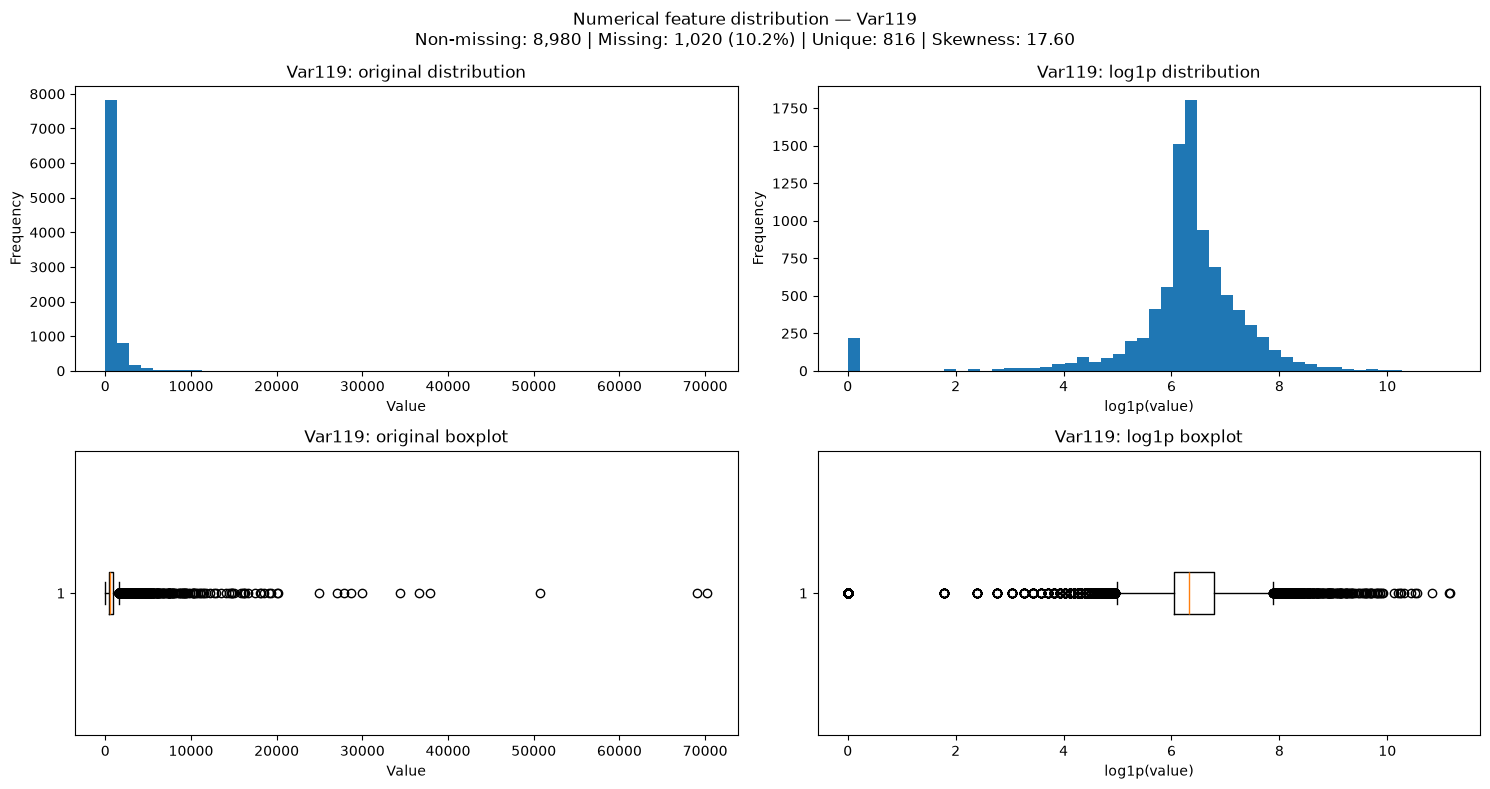

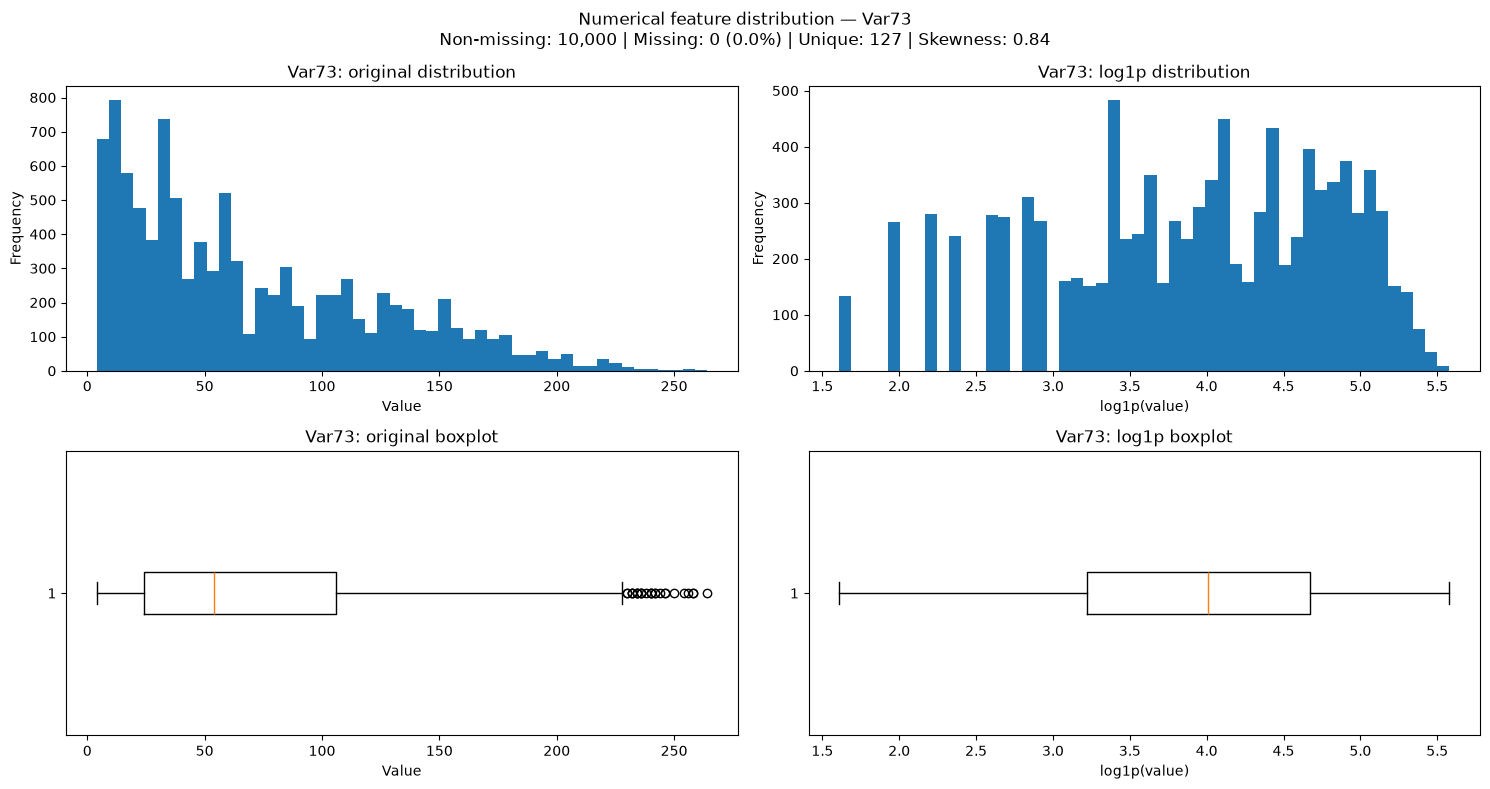

In [23]:
interesting_numeric_features = [
    "Var83",    # Highest skewness
    "Var125",   # Very high cardinality and extreme range
    "Var173",   # Nearly binary
    "Var174",   # Very high missing rate
    "Var119",   # High cardinality
    "Var73",    # Integer feature
]

for column in interesting_numeric_features:
    figure = plot_numeric_distribution(
        data.X,
        column,
        include_log=True,
    )
    plt.show()

### Key Findings

- Numerical features exhibit diverse distribution patterns rather than a single common structure. The dataset contains highly skewed continuous variables, sparse count-like features, nearly binary variables, and moderately skewed integer features.
- Several numerical features contain a large proportion of zero values combined with extreme positive outliers. Logarithmic transformation substantially improves the visualization of the positive-value distribution for these variables, suggesting that log-transformed representations should be evaluated during feature engineering.
- Features with extremely high missing rates (for example, Var174) appear to carry information through both the presence of missing values and the observed values themselves. This suggests that missing-value indicators may be useful in future experiments.
- Some numerical variables (for example, Var173) behave as binary indicators despite being stored as numeric values. Such features may require a different preprocessing strategy than continuous variables.
- Not all numerical features benefit equally from logarithmic transformation. Moderately skewed variables such as Var73 retain an interpretable distribution in their original scale, indicating that feature-specific preprocessing is likely to outperform a single global transformation strategy.
- The exploratory analysis indicates that multiple feature engineering approaches should be evaluated during model development, including logarithmic transformation, missing-value indicators, zero-value indicators, and alternative representations for sparse numerical features.

### EDA Implications
- The exploratory analysis suggests that numerical features should not be treated uniformly during preprocessing. Different groups of variables are likely to require different feature engineering strategies.
- Several highly skewed variables became substantially more interpretable after logarithmic transformation, making log-transformed representations promising candidates for future experiments.
- Sparse numerical features containing many zero values or missing observations may benefit from additional indicator variables describing the presence of zeros or missing values.
- Some numerical variables behave as binary indicators despite being stored as numeric values and should be evaluated separately during preprocessing.
- The observations from the EDA will be used to design and compare multiple preprocessing pipelines during model development rather than applying a single transformation strategy to all features.

## Categorical Feature Distributions

In [24]:
categorical_summary = analyze_categorical_features(data.X)

display(categorical_summary)

,column,dtype,n_rows,n_present,n_missing,missing_rate,n_unique,top_category,top_count,top_rate,rare_category_count,rare_value_count,rare_value_rate
0,Var217,object,10000,9872,128,0.0128,5529,gvA6,49,0.0049,5529,9872,0.9872
1,Var200,object,10000,5043,4957,0.4957,4478,yP09M03,16,0.0016,4478,5043,0.5043
2,Var214,object,10000,5043,4957,0.4957,4478,5zARyjR,16,0.0016,4478,5043,0.5043
3,Var202,object,10000,10000,0,0.0000,3802,nyZz,35,0.0035,3802,10000,1.0000
4,Var198,object,10000,10000,0,0.0000,2100,fhk21Ss,956,0.0956,2095,8351,0.8351
5,Var220,object,10000,10000,0,0.0000,2100,4UxGlow,956,0.0956,2095,8351,0.8351
6,Var222,object,10000,10000,0,0.0000,2100,catzS2D,956,0.0956,2095,8351,0.8351
7,Var199,object,10000,10000,0,0.0000,1850,r83_sZi,213,0.0213,1836,8217,0.8217
8,Var216,object,10000,10000,0,0.0000,977,mAjbk_S,931,0.0931,959,4348,0.4348
9,Var192,object,10000,9921,79,0.0079,297,8I1r4RXXnK,92,0.0092,297,9921,0.9921


In [25]:
experiment.save_dataframe(
    categorical_summary,
    "categorical_feature_summary.csv",
)

WindowsPath('artifacts/experiments/20260722_210807_eda_002_missing_values_analysis/reports/categorical_feature_summary.csv')

### Categorical Feature Profiles

In [26]:
cardinality_profile = (
    categorical_summary
    .assign(
        cardinality_group=lambda df:
            df["n_unique"].apply(categorize_cardinality)
    )
    .groupby("cardinality_group")
    .size()
    .rename("Feature count")
    .reset_index()
)

display(cardinality_profile)

,cardinality_group,Feature count
0,Binary,4
1,Constant,4
2,High (>200),10
3,Low (11–50),7
4,Medium (51–200),3
5,Very low (3–10),10


In [27]:
missing_profile = (
    categorical_summary
    .assign(
        missing_group=lambda df:
            df["missing_rate"].apply(categorize_missing_rate)
    )
    .groupby("missing_group")
    .size()
    .rename("Feature count")
    .reset_index()
)

display(missing_profile)

,missing_group,Feature count
0,High (50–75%),4
1,Low (<25%),10
2,Moderate (25–50%),2
3,No missing,18
4,Very high (75–100%),4


In [28]:
dominance_profile = (
    categorical_summary
    .assign(
        dominance_group=lambda df:
            df["top_rate"].apply(categorize_top_rate)
    )
    .groupby("dominance_group")
    .size()
    .rename("Feature count")
    .reset_index()
)

display(dominance_profile)

,dominance_group,Feature count
0,Balanced (<50%),22
1,Dominant (80–95%),4
2,Moderately dominant (50–80%),9
3,Very dominant (>95%),3


### Key Observations

The categorical feature set contains a diverse mix of feature types.

Several variables exhibit extremely high cardinality, while others are dominated by a single category or contain a substantial proportion of missing values. These characteristics suggest that different preprocessing strategies may be required depending on the feature profile.

In [30]:
interesting_categorical_features = [
    "Var217",  # Extremely high cardinality and long tail
    "Var198",  # High cardinality with dominant categories
    "Var226",  # Regular low-cardinality categorical feature
    "Var196",  # Nearly constant categorical feature
    "Var229",  # Low cardinality with high missing rate
]

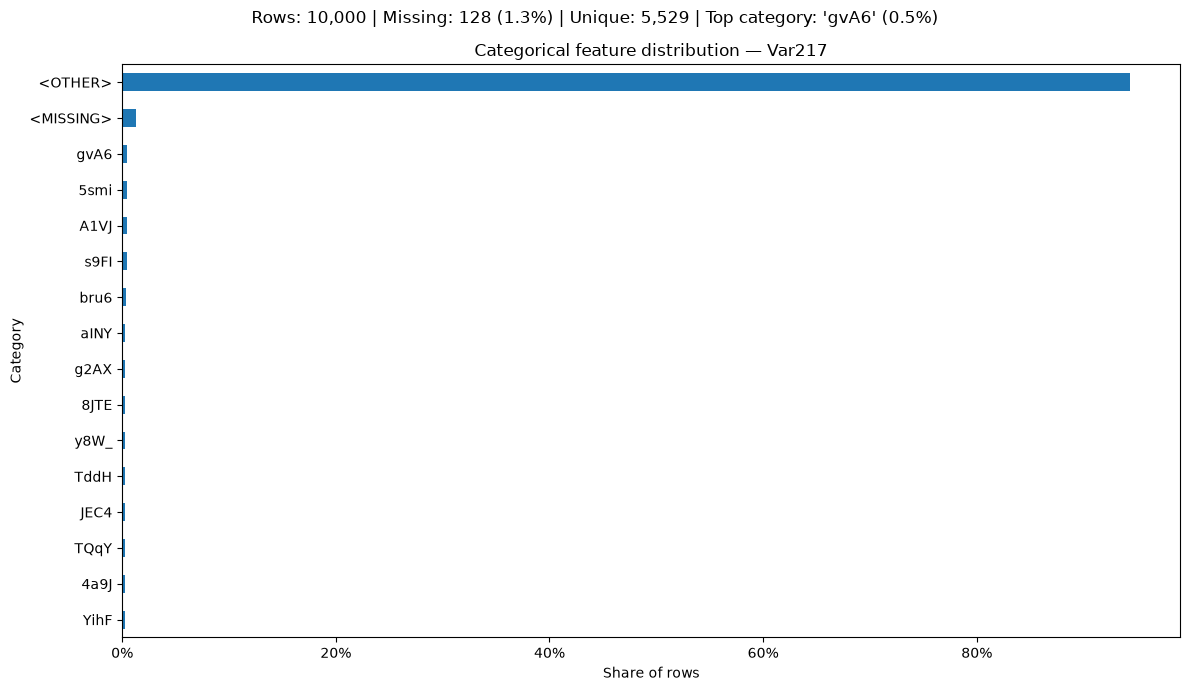

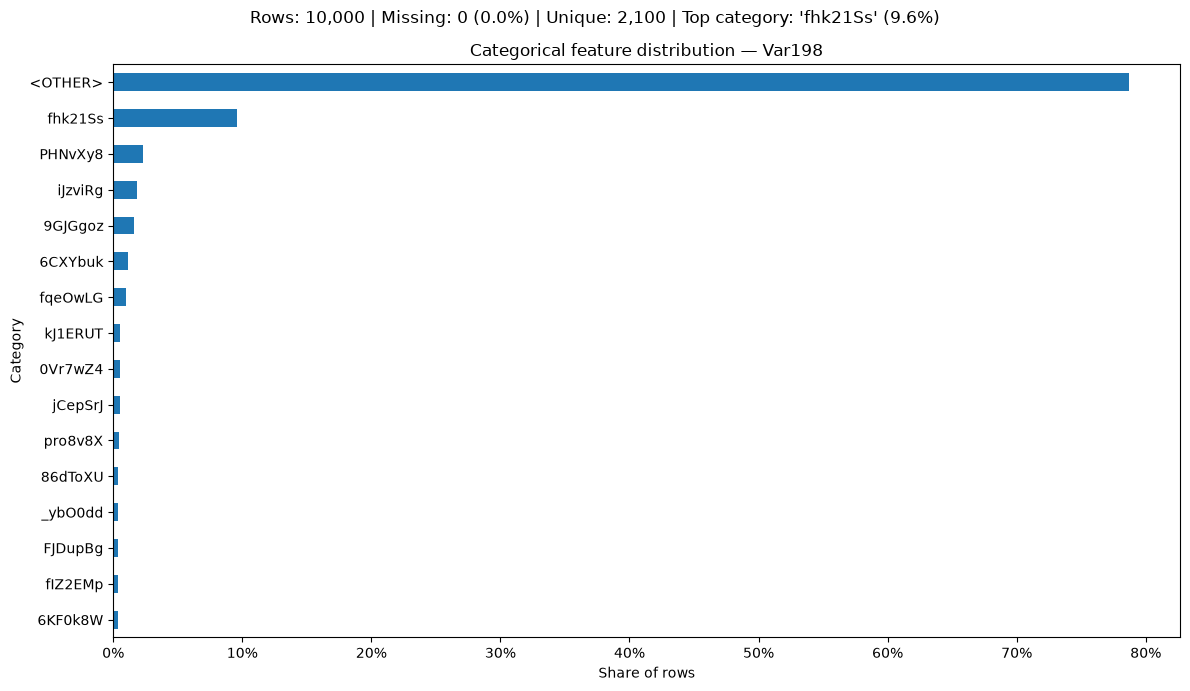

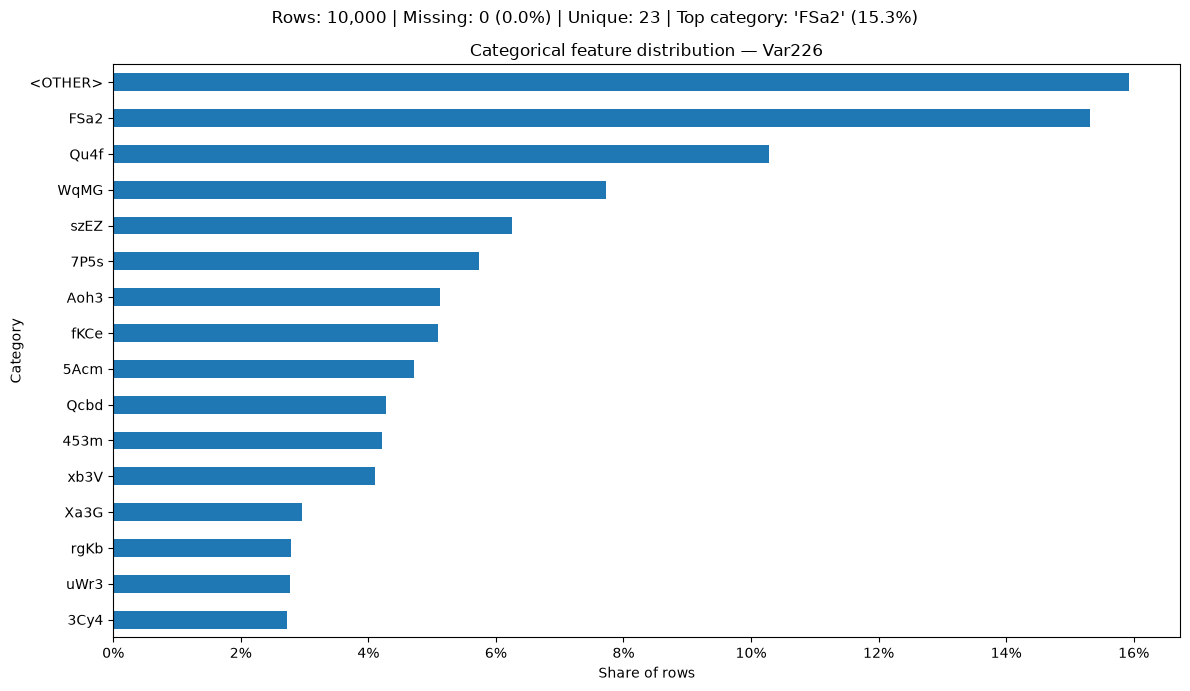

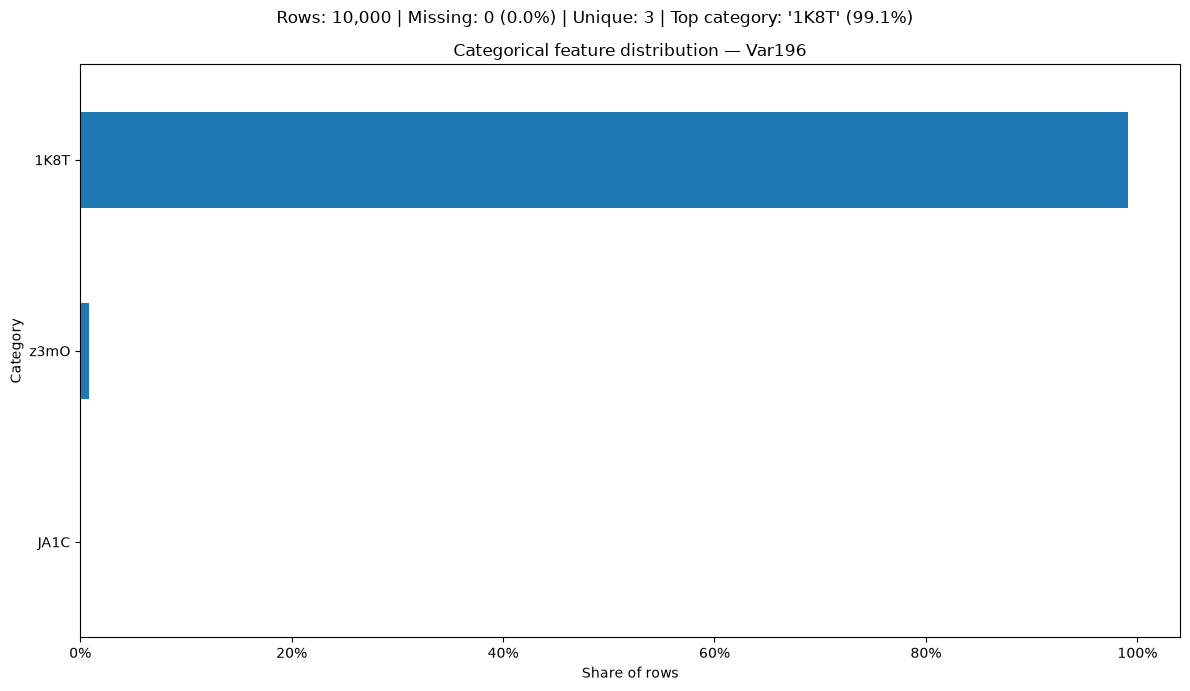

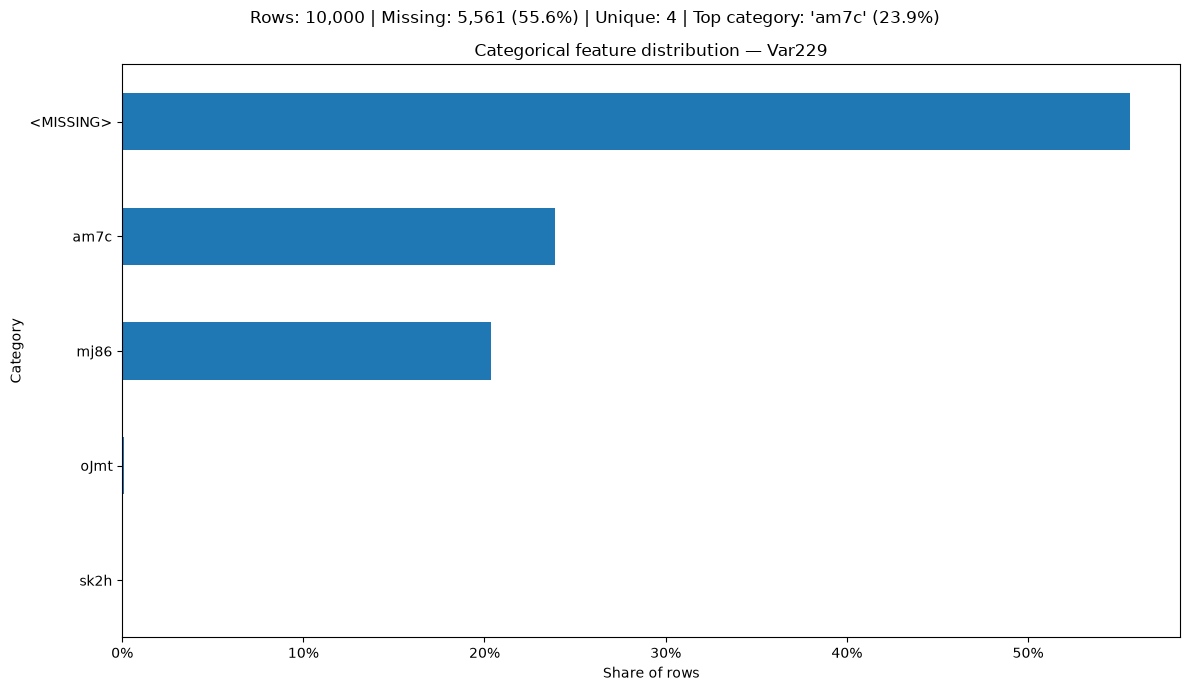

In [31]:
for column in interesting_categorical_features:
    figure = plot_categorical_distribution(
        data.X,
        column,
        top_n=15,
        normalize=True,
        include_missing=True,
        group_remaining=True,
    )
    plt.show()

### Key Findings

## EDA Summary